## IPL Death Overs Win Probability Analysis


In [1]:
%pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Setup and Data Loading

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
deliveries = pd.read_csv("deliveries.csv")
matches = pd.read_csv("matches.csv")

df = deliveries.merge(matches, left_on='match_id', right_on='id')

### Data Preparation

In [3]:
df2 = df[df['inning'] == 2].copy()

In [4]:
df_15 = df2[df2['over'] <= 15]

state_15 = df_15.groupby('match_id').agg({
    'total_runs': 'sum',
    'is_wicket': 'sum',
    'batting_team': 'last',
    'bowling_team': 'last',
    'season': 'last'
}).reset_index()

state_15.rename(columns={
    'total_runs': 'score_15',
    'is_wicket': 'wickets_lost'
}, inplace=True)

state_15['wickets_left'] = 10 - state_15['wickets_lost']

In [5]:
df1 = df[df['inning'] == 1]
target = df1.groupby('match_id')['total_runs'].sum().reset_index()
target.rename(columns={'total_runs': 'target'}, inplace=True)
state_15 = state_15.merge(target, on='match_id')

In [6]:
state_15['runs_left'] = state_15['target'] - state_15['score_15']
state_15['balls_left'] = 30
state_15['req_rr'] = state_15['runs_left'] / (state_15['balls_left'] / 6)

In [7]:
winner = matches[['id', 'winner']]
state_15 = state_15.merge(winner, left_on='match_id', right_on='id')
state_15.drop(columns=['id'], inplace=True)
state_15['chasing_win'] = (state_15['batting_team'] == state_15['winner']).astype(int)

In [8]:
state_15 = state_15.dropna()
state_15 = state_15[state_15['runs_left'] >= 0]

In [9]:
le = LabelEncoder()
state_15['batting_team_enc'] = le.fit_transform(state_15['batting_team'])
state_15['bowling_team_enc'] = le.fit_transform(state_15['bowling_team'])
state_15['runs_per_wicket'] = state_15['score_15'] / (10 - state_15['wickets_left'] + 1)
state_15['pressure_index'] = state_15['req_rr'] / (state_15['wickets_left'] + 1)

### Model Training

In [10]:
features = [
    'score_15',
    'wickets_left',
    'req_rr',
    'batting_team_enc',
    'bowling_team_enc'
]
X = state_15[features]
y = state_15['chasing_win']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

In [12]:
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [13]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.81
              precision    recall  f1-score   support

           0       0.84      0.78      0.81       103
           1       0.78      0.85      0.81        97

    accuracy                           0.81       200
   macro avg       0.81      0.81      0.81       200
weighted avg       0.81      0.81      0.81       200



### Model Evaluation

In [14]:
sample = pd.DataFrame([{
    'score_15': 120,
    'wickets_left': 9,
    'req_rr': 10,
    'batting_team_enc': le.transform(['Mumbai Indians'])[0],
    'bowling_team_enc': le.transform(['Chennai Super Kings'])[0]
}])
prob = model.predict_proba(sample)[0][1]
print("Win Probability:", prob)

Win Probability: 0.65


In [15]:
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)
print(feature_importance_df)

            Feature  Importance
2            req_rr    0.467369
1      wickets_left    0.213508
0          score_15    0.147123
3  batting_team_enc    0.095069
4  bowling_team_enc    0.076930


### Analysis and Visualization


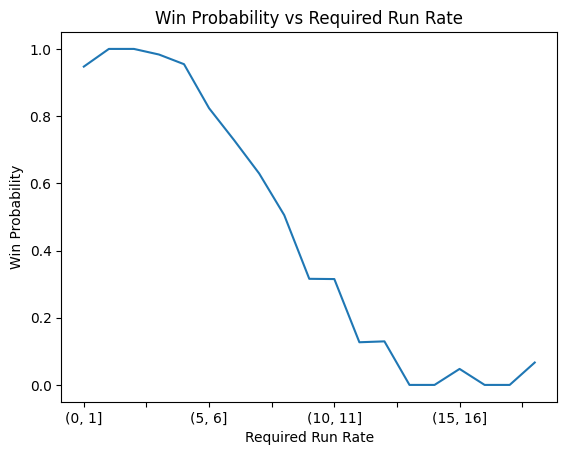

In [32]:
state_15['rr_bin'] = pd.cut(state_15['req_rr'], bins=np.arange(0, 20, 1))
rr_win = state_15.groupby('rr_bin')['chasing_win'].mean()
plt.figure()
rr_win.plot()
plt.xlabel("Required Run Rate")
plt.ylabel("Win Probability")
plt.title("Win Probability vs Required Run Rate")
plt.show()

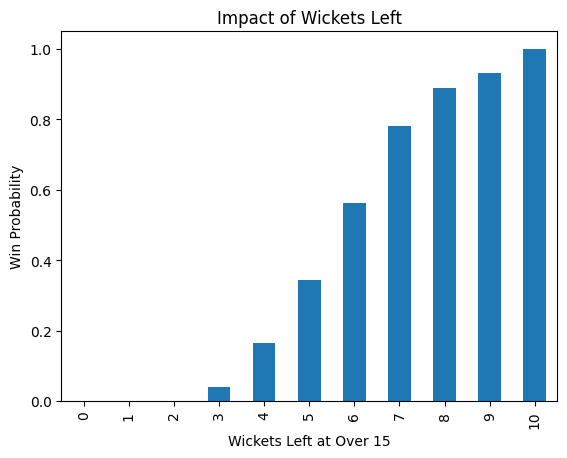

In [34]:
wicket_win = state_15.groupby('wickets_left')['chasing_win'].mean()
plt.figure()
wicket_win.plot(kind='bar')
plt.xlabel("Wickets Left at Over 15")
plt.ylabel("Win Probability")
plt.title("Impact of Wickets Left")
plt.show()

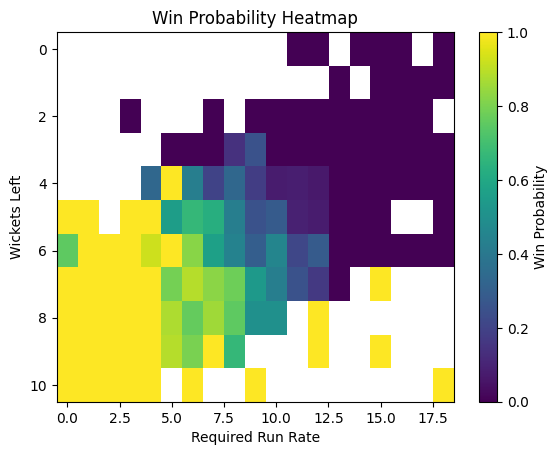

In [18]:
pivot = state_15.pivot_table(
    values='chasing_win',
    index='wickets_left',
    columns='rr_bin',
    aggfunc='mean'
)

plt.figure()
plt.imshow(pivot, aspect='auto')
plt.colorbar(label='Win Probability')
plt.xlabel("Required Run Rate")
plt.ylabel("Wickets Left")
plt.title("Win Probability Heatmap")
plt.show()

### Prediction

In [19]:
def predict_win(score_15,wickets_left,target,batting_team,bowling_team):
    runs_left = target - score_15
    balls_left = 30
    req_rr = runs_left/(balls_left/6)
    input_df = pd.DataFrame([{
        'score_15': score_15,
        'wickets_left': wickets_left,
        'req_rr': req_rr,
        'batting_team_enc': le.transform([batting_team])[0],
        'bowling_team_enc': le.transform([bowling_team])[0]
    }])
    prob = model.predict_proba(input_df)[0][1]
    print(f"\nWin Probability: {prob:.2f}")

In [35]:
# score = int(input("Score at 15 overs: "))
# wickets = int(input("Wickets left: "))
# target = int(input("Target: "))
# batting = input("Batting team: ")
# bowling = input("Bowling team: ")
score = 130
wickets = 6
target = 160
batting ="Mumbai Indians"
bowling ="Punjab Kings"
print("Score at 15 overs:",score)
print("Wickets left:",wickets)
print("Target:",target)
print("Batting team:",batting)
print("Bowling team:",bowling)
predict_win(score, wickets, target, batting, bowling)

Score at 15 overs: 130
Wickets left: 6
Target: 160
Batting team: Mumbai Indians
Bowling team: Punjab Kings

Win Probability: 0.96
